In [1]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

import plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

def tf(zeta):
    return zeta*zeta*zeta*(10.-15.*zeta+6.*zeta*zeta)
def tfd(zeta):
    return 30.*zeta*zeta*(1.-2.*zeta+zeta*zeta)

In [2]:
output_folder   = "./data/janmeyen_241201"
fpath = os.path.join("/export/data2/model/jawara","jawara_janmeyen_241201.nc")

In [3]:
"""JAWARA background profile (average over one area)"""
ds_jawara = xr.open_dataset(fpath)

"""Reduce area"""
# lats = slice(-52,-60)
# # lats = slice(-44,-50)
# lons = slice(278,286)
# ds_jawara = ds_jawara.sel(latitude=lats, longitude=lons)

ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))

"""Average and trim"""
ds_jawara = ds_jawara.mean(dim=["latitude","longitude"])

ds_jawara

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 336, level: 350)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-12-01 ... 2024-12-14T23:00:00
  * level    (level) int64 3kB 0 400 800 1200 ... 138400 138800 139200 139600
Data variables:
    u        (time, level) float64 941kB -1.831 -5.029 -6.353 ... -32.22 -32.7
    v        (time, level) float64 941kB -8.956 -11.33 -10.98 ... -8.614 -8.196
    p        (time, level) float64 941kB 1.019e+05 9.677e+04 ... 0.0003913
    t        (time, level) float64 941kB 265.8 262.0 258.7 ... 568.3 572.5 576.6
    th       (time, level) float64 941kB 264.4 264.5 ... 1.498e+05 1.517e+05
    rho      (time, level) float64 941kB 1.341 1.292 ... 2.35e-09 2.277e-09
    N        (time, level) float64 941kB 0.004475 0.005108 ... 0.01766 0.0176

In [ ]:
"""JAWARA background profile (select one point)"""
ds_jawara = xr.open_dataset(fpath)

"""Select point"""
# lon = 360-73
# lat = -55.5
lon = 360-67.5 # CORAL
lat = -53.5 # CORAL
ds_jawara = ds_jawara.sel(latitude=lat, longitude=lon, method="nearest")

ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level'], (g * np.gradient(logth, 400, axis=1))**(1/2))

"""Average and trim"""
# ds['var'].values = scipy.ndimage.gaussian_filter(ds[var].values, sigma, axes=1)
ds_jawara

<xarray.Dataset> Size: 944kB
Dimensions:    (time: 48, level: 350)
Coordinates:
  * time       (time) datetime64[ns] 384B 2018-05-21 ... 2018-05-22T23:00:00
  * level      (level) int64 3kB 0 400 800 1200 ... 138400 138800 139200 139600
    latitude   float32 4B -54.42
    longitude  float32 4B 292.5
Data variables:
    u          (time, level) float64 134kB ...
    v          (time, level) float64 134kB ...
    p          (time, level) float64 134kB 1.002e+05 9.536e+04 ... 0.0004148
    t          (time, level) float64 134kB ...
    th         (time, level) float64 134kB 277.8 278.7 ... 1.461e+05 1.479e+05
    rho        (time, level) float64 134kB 1.26 1.213 ... 2.508e-09 2.436e-09
    N          (time, level) float64 134kB 0.008851 0.008974 ... 0.01692 0.01687

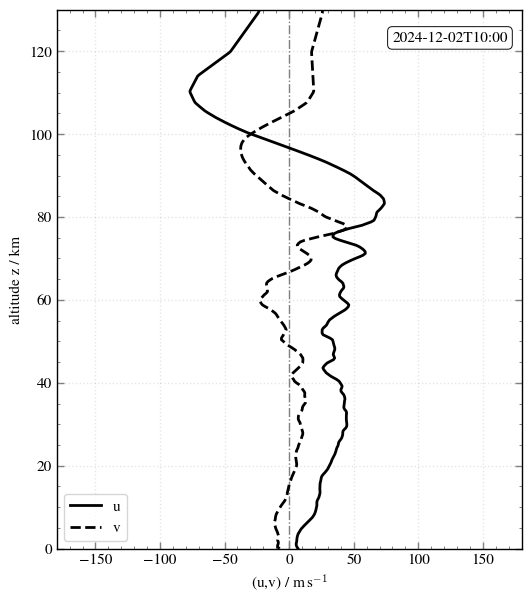

In [ ]:
def plot_wind(t, ds, folder, usmooth=None, vsmooth=None):
    fig, ax_wind = plt.subplots(1, 1, figsize=(6, 7))

    ut  = ds['u'].values
    vt  = ds['v'].values
    levels = ds['level'].values
    time = ds['time'][t].values

    """Wind profile plot"""
    lwl = 2
    lws = 1.5
    ax_wind.axvline(0, ls="-.", lw=1, color='grey')

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-180, 180])
    ax_wind.set_ylim([0, 130])
    # ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right=True, bottom=True, left=True, 
                        labelbottom=True, labeltop=False, color="grey")
    ax_wind.grid()

    ax_wind.text(0.97, 0.96, np.datetime_as_string(time, unit='m'), transform=ax_wind.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
         

    ax_wind.plot(ut[t,:], levels/1000, lw=lwl, ls='-',  color="black", label="u")
    ax_wind.plot(vt[t,:], levels/1000, lw=lwl, ls='--', color="black", label="v")

    if usmooth is not None:
        ax_wind.plot(usmooth, levels[:len(usmooth)]/1000, lw=lws, ls='-',  color="royalblue", label="u_env")
        ax_wind.plot(vsmooth, levels[:len(usmooth)]/1000, lw=lws, ls='--', color="coral", label="v_env")
    ax_wind.legend(loc="lower left")

    """Save figure"""
    os.makedirs(folder, exist_ok=True)
    fig_name = 'wind_' + '{:03d}'.format(t) + '.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')

# tstamp = 28
tstamp = 34
plot_wind(tstamp, ds_jawara, output_folder)

In [7]:
%%capture
animation_folder = os.path.join(output_folder, 'wind_animation')
for t in range(np.shape(ds_jawara['u'])[0]):
    plot_wind(t, ds_jawara, animation_folder)
plt_helper.create_animation(animation_folder, os.path.join(output_folder, "wind_animation.mp4"),fps=10)

umax: 8.64572754614027


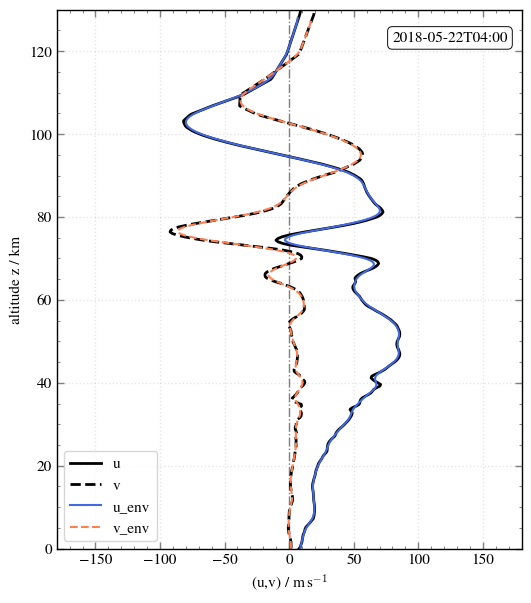

In [ ]:
"""Get JAWARA profiles for EULAG vertical grid"""
l = 321
ds = ds_jawara.isel(time=slice(tstamp-4,tstamp+4))
dsm = ds.mean(dim=["time"])

th = dsm['th'].values[0:l]
rho = dsm['rho'].values[0:l]
p = dsm['p'].values[0:l]
N  = (g/th * np.gradient(th, 400))**(1/2)
temp = th*(rho*Rd*th/p0)**(Rd/(cp-Rd))

u = ds_jawara['u'][tstamp,0:l].values
v = ds_jawara['v'][tstamp,0:l].values

levels = ds['level'][0:l].values
sigma = 5
lb =30
# u[lb:] = scipy.ndimage.gaussian_filter(u[lb:], sigma, axes=0)   
# v[lb:] = scipy.ndimage.gaussian_filter(v[lb:], sigma, axes=0)   
th = scipy.ndimage.gaussian_filter(th, sigma, axes=0)   
rho = scipy.ndimage.gaussian_filter(rho, sigma, axes=0)

sigma = 5
# sigma = 2.5
lb =30
u = scipy.ndimage.gaussian_filter(u, sigma, axes=0)   
v = scipy.ndimage.gaussian_filter(v, sigma, axes=0)
plot_wind(tstamp, ds_jawara, output_folder, usmooth=u, vsmooth=v)
print(f"umax: {u[0]}")

/tmp/ipykernel_6626/1881158552.py:104: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: AutoMinorLocator does not work with logarithmic scale
  func(*args, **kwargs)
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


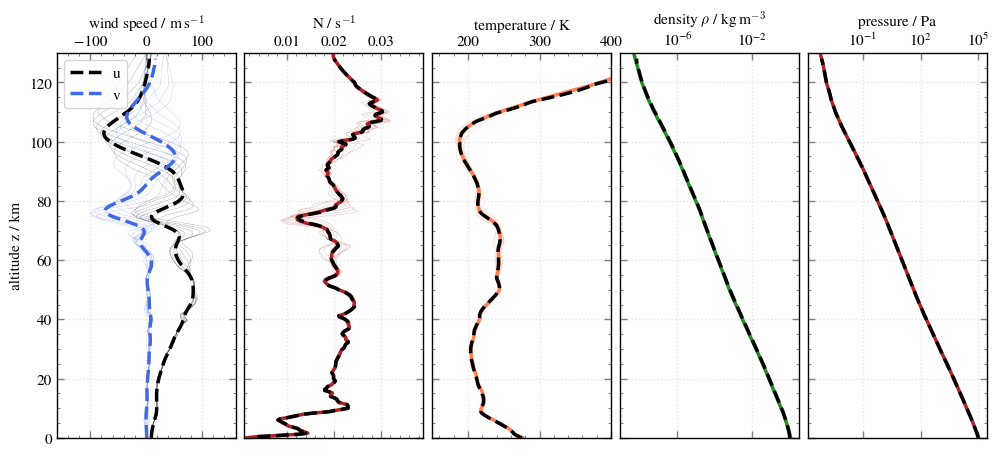

In [40]:
"""Vis env"""
# fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={'projection': ccrs.LambertConformal()})
fig, axes = plt.subplots(1,5, figsize=(12,5),sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.05})
ax_wind  = axes[0]
ax_n     = axes[1]
ax_t     = axes[2]
ax_rho   = axes[3]
ax_p     = axes[4]

# ax.set_aspect("equal", adjustable='datalim')
"""Wind"""
lws = 0.1
lwl = 2.5
cu = "black"
cv = "royalblue"
for t in range(len(ds.time)):
    ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color=cu)
    ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color=cv)
# ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, color="royalblue", label="u")
# ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, color="skyblue", label="v")
ax_wind.plot(u, levels/1000, lw=lwl, ls='--', color=cu, label="u")
# ax_wind.plot(uphase1, levels/1000, lw=lwl, ls='dotted', color=cu)
ax_wind.plot(v, levels/1000, lw=lwl, ls='--', color=cv, label="v")
# ax_wind.plot(vphase1, levels/1000, lw=lwl, ls='dotted', color=cv)
ax_wind.legend(loc="upper left")

ax_wind.set_xlabel("wind speed / m$\,$s$^{-1}$")
ax_wind.set_ylabel("altitude z / km")
ax_wind.set_xlim([-160,160])
ax_wind.set_xticks([-100,0,100])
ax_wind.set_ylim([0,130])
ax_wind.xaxis.set_label_position('top')
ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
ax_wind.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_wind.grid()


"""N"""
for t in range(len(ds.time)):
    ax_n.plot(ds["N"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_n.plot(dsm["N"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_n.plot(N, levels/1000, lw=lwl, ls='--', color="black")
ax_n.set_xlabel("N / s$^{-1}$")
ax_n.set_xlim([0.001,0.039])

ax_n.xaxis.set_label_position('top')
ax_n.xaxis.set_minor_locator(AutoMinorLocator())
ax_n.yaxis.set_minor_locator(AutoMinorLocator())
ax_n.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_n.grid()

"""T"""
for t in range(len(ds.time)):
    ax_t.plot(ds["t"][t], ds["level"]/1000, lw=lws, color="coral")
ax_t.plot(dsm["t"], dsm["level"]/1000, lw=lwl, color="coral")
ax_t.plot(temp, levels/1000, lw=lwl, ls='--', color="black")

ax_t.set_xlabel("temperature / K")
ax_t.set_xlim(150,400)

ax_t.xaxis.set_label_position('top')
ax_t.xaxis.set_minor_locator(AutoMinorLocator())
ax_t.yaxis.set_minor_locator(AutoMinorLocator())
ax_t.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_t.grid()


"""Rho"""
for t in range(len(ds.time)):
    ax_rho.plot(ds["rho"][t], ds["level"]/1000, lw=lws, color="forestgreen")
ax_rho.plot(dsm["rho"], dsm["level"]/1000, lw=lwl, color="forestgreen")
ax_rho.plot(rho, levels/1000, lw=lwl, ls='--', color="black")
ax_rho.set_xlabel("density $\\rho$ / kg$\,$m$^{-3}$")
ax_rho.set_xscale('log')

ax_rho.xaxis.set_label_position('top')
ax_rho.xaxis.set_minor_locator(AutoMinorLocator())
ax_rho.yaxis.set_minor_locator(AutoMinorLocator())
ax_rho.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_rho.grid()

"""Pressure / Theta"""
for t in range(len(ds.time)):
    ax_p.plot(ds["p"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_p.plot(dsm["p"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_p.plot(p, levels/1000, lw=lwl, ls='--', color="black")
# ax_p.set_xlabel("$\Theta$ / K")
ax_p.set_xlabel("pressure / Pa")
# ax_p.set_xticks([2500,5000,7500])
ax_p.set_xscale('log')


ax_p.xaxis.set_label_position('top')
ax_p.xaxis.set_minor_locator(AutoMinorLocator())
ax_p.yaxis.set_minor_locator(AutoMinorLocator())
ax_p.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_p.grid()


"""Save figure"""
folder   = "./data/darwin_180522"
fig_name = f"env_180522_tstamp_{tstamp}.png"
fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'

In [62]:
"""Create NETCDF"""
ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

fname = "jawara_180522T10_400m_l321.nc"
# fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("./data/envs", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'

In [44]:
ds

<xarray.Dataset> Size: 13kB
Dimensions:  (level: 321)
Coordinates:
  * level    (level) int64 3kB 0 400 800 1200 ... 126800 127200 127600 128000
Data variables:
    u        (level) float64 3kB 13.67 14.68 16.22 17.73 ... 6.692 6.903 7.01
    v        (level) float64 3kB 3.813 4.479 5.502 6.536 ... 10.61 10.65 10.67
    th       (level) float64 3kB 280.7 280.8 281.2 ... 9.98e+04 1.001e+05
    rho      (level) float64 3kB 1.113 1.107 1.094 ... 5.916e-09 5.872e-09

In [66]:
# import shutil
# shutil.rmtree(folder)
folder = "../data/eulag/figures/saamer_JJA"
plt_helper.create_animation(folder,os.path.join(folder,"saamer_May.mp4"), fps=5)